# Wavelet analysis of simulated FRB microshot forests

Workflow:

```text
saved WILL .npz bursts
→ 1D profile + dynamic spectrum
→ ACF/peak metrics
→ 1D wavelet scalogram
→ dynamic-spectrum time-wavelet metric
→ compare with FLITS residual metrics
```


In [21]:
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, signal, stats

warnings.filterwarnings(
    "ignore",
    message="scipy.stats.shapiro: For N > 5000.*",
    category=UserWarning,
)

BURST_DIR = Path("will_flits_microshot_package/will_microshot_outputs/npz")
FLITS_RESULTS_CSV = Path("flits_direct_results_2/flits_microshot_results.csv")
OUT_DIR = Path("wavelet_microshot_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_TSAMP_MS = 0.016
PEAK_SIGMA_THRESHOLD = 5.0
MIN_PEAK_DISTANCE_MS = 0.02

CROP_THRESHOLD_SIGMA = 5.0
CROP_MARGIN_MS = 2.0
MAX_CROP_MS = 20.0

WAVELET_SCALE_MIN_MS = 0.016
WAVELET_SCALE_MAX_MS = 4.0
N_WAVELET_SCALES = 48
SHORT_SCALE_MAX_MS = 0.25
WAVELET_EXCESS_SNR_THRESHOLD = 3.0

# This is not a full 2D wavelet transform. It applies the time wavelet to each frequency channel.
RUN_DYNAMIC_SPECTRUM_TIME_WAVELET = False
# RUN_DYNAMIC_SPECTRUM_TIME_WAVELET = True

print("Burst directory:", BURST_DIR.resolve())
print("FLITS table exists:", FLITS_RESULTS_CSV.exists(), FLITS_RESULTS_CSV)
print("Output directory:", OUT_DIR.resolve())

Burst directory: /home/giannis/Astrovaria/will_flits_microshot_package/will_microshot_outputs/npz
FLITS table exists: True flits_direct_results_2/flits_microshot_results.csv
Output directory: /home/giannis/Astrovaria/wavelet_microshot_results


## Loading and preprocessing functions

These functions load each saved burst, orient the dynamic spectrum as `(time, frequency)`, normalize the 1D profile, and define a short crop around the burst.

In [2]:
def npz_scalar(d, key, default=np.nan):
    if key not in d.files:
        return default
    x = d[key]
    if np.shape(x) == ():
        return x.item()
    return x


def robust_median_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0, 1.0
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    sig = 1.4826 * mad
    if not np.isfinite(sig) or sig <= 0:
        sig = np.nanstd(x)
    if not np.isfinite(sig) or sig <= 0:
        sig = 1.0
    return float(med), float(sig)


def orient_dynamic_spectrum(ds, ntime=None, nfreq=None):
    ds = np.asarray(ds, dtype=float)
    if ds.ndim != 2:
        raise ValueError(f"dynamic_spectrum must be 2D, got shape {ds.shape}")
    nt, nf = ds.shape
    if ntime is not None and nt == ntime:
        return ds
    if ntime is not None and nf == ntime:
        return ds.T
    if nfreq is not None and nf == nfreq:
        return ds
    if nfreq is not None and nt == nfreq:
        return ds.T
    return ds if ds.shape[0] >= ds.shape[1] else ds.T


def load_burst_npz(path):
    path = Path(path)
    with np.load(path, allow_pickle=True) as d:
        burst_id = str(npz_scalar(d, "burst_id", path.stem))
        tsamp_ms = float(npz_scalar(d, "tsamp_ms", DEFAULT_TSAMP_MS))
        dm = float(npz_scalar(d, "dm", np.nan))
        input_n_peaks = npz_scalar(d, "input_n_peaks", np.nan)
        if not np.isfinite(input_n_peaks):
            m = re.search(r"_n(\d+)_", burst_id)
            input_n_peaks = int(m.group(1)) if m else np.nan

        if "t_ms" in d.files:
            t_ms = np.asarray(d["t_ms"], dtype=float)
        elif "time_ms" in d.files:
            t_ms = np.asarray(d["time_ms"], dtype=float)
        else:
            nt_guess = d["profile"].shape[0] if "profile" in d.files else d["dynamic_spectrum"].shape[0]
            t_ms = np.arange(nt_guess) * tsamp_ms

        freqs_mhz = None
        for key in ["chan_freqs_mhz", "freqs_mhz", "frequency_mhz", "freq_mhz"]:
            if key in d.files:
                freqs_mhz = np.asarray(d[key], dtype=float)
                break

        if "dynamic_spectrum" in d.files:
            ds_raw = np.asarray(d["dynamic_spectrum"], dtype=float)
            ds = orient_dynamic_spectrum(ds_raw, ntime=len(t_ms), nfreq=None if freqs_mhz is None else len(freqs_mhz))
        else:
            ds = None

        if "profile" in d.files:
            profile = np.asarray(d["profile"], dtype=float).ravel()
            if profile.shape[0] != len(t_ms):
                profile = profile[:len(t_ms)]
        elif ds is not None:
            profile = np.nanmean(ds, axis=1)
        else:
            raise ValueError(f"{path} has neither profile nor dynamic_spectrum")

        if freqs_mhz is None and ds is not None:
            freqs_mhz = np.arange(ds.shape[1], dtype=float)

    return dict(
        path=path,
        file=str(path),
        burst_id=burst_id,
        dm=dm,
        input_n_peaks=input_n_peaks,
        tsamp_ms=tsamp_ms,
        t_ms=t_ms,
        freqs_mhz=freqs_mhz,
        dynamic_spectrum=ds,
        profile=profile,
    )


def find_npz_files(burst_dir):
    burst_dir = Path(burst_dir)
    files = sorted(burst_dir.glob("*.npz"))
    if not files:
        files = sorted(burst_dir.rglob("*.npz"))
    if not files:
        raise FileNotFoundError(f"No .npz files found under {burst_dir.resolve()}")
    return files


def normalize_profile(profile):
    med, sig = robust_median_std(profile)
    return (np.asarray(profile, dtype=float) - med) / sig, med, sig


def find_burst_crop(t_ms, profile_norm, threshold_sigma=CROP_THRESHOLD_SIGMA,
                    margin_ms=CROP_MARGIN_MS, max_crop_ms=MAX_CROP_MS):
    t_ms = np.asarray(t_ms, dtype=float)
    y = np.asarray(profile_norm, dtype=float)
    dt = float(np.nanmedian(np.diff(t_ms)))
    above = np.where(y > threshold_sigma)[0]
    if above.size == 0:
        peak = int(np.nanargmax(y))
        pad = int(round(margin_ms / dt))
        start = max(0, peak - pad)
        stop = min(len(y), peak + pad + 1)
    else:
        pad = int(round(margin_ms / dt))
        start = max(0, above.min() - pad)
        stop = min(len(y), above.max() + pad + 1)

    duration = t_ms[stop - 1] - t_ms[start] if stop > start else 0
    if duration > max_crop_ms:
        peak = int(np.nanargmax(y))
        half = int(round(0.5 * max_crop_ms / dt))
        start = max(0, peak - half)
        stop = min(len(y), peak + half + 1)

    mask = np.zeros_like(y, dtype=bool)
    mask[start:stop] = True
    return start, stop, mask

## ACF and peak metrics

These are included so the wavelet metrics can be compared directly to ACF width, peak count, peak rate, separation statistics, and burst duration.

In [3]:
def gaussian_acf_model(lag, amp, sigma, offset):
    return offset + amp * np.exp(-0.5 * (lag / sigma) ** 2)


def compute_acf_sigma(t_ms, profile_norm, crop_mask=None, max_lag_ms=5.0):
    y = np.asarray(profile_norm, dtype=float)
    if crop_mask is not None and np.any(crop_mask):
        y = y[crop_mask]
    y = y - np.nanmean(y)
    if y.size < 5 or np.nanstd(y) <= 0:
        return np.nan, np.nan
    acf = signal.correlate(y, y, mode="full", method="auto")
    acf = acf[acf.size // 2:]
    if acf[0] != 0:
        acf = acf / acf[0]
    dt = float(np.nanmedian(np.diff(t_ms)))
    lags = np.arange(acf.size) * dt
    fit_mask = (lags > 0) & (lags <= max_lag_ms) & np.isfinite(acf)
    if fit_mask.sum() < 5:
        return np.nan, np.nan
    try:
        popt, _ = optimize.curve_fit(
            gaussian_acf_model,
            lags[fit_mask],
            acf[fit_mask],
            p0=(1.0, min(0.2, max_lag_ms / 4), 0.0),
            bounds=([0.0, dt, -0.5], [2.0, max_lag_ms, 0.5]),
            maxfev=5000,
        )
        model = gaussian_acf_model(lags[fit_mask], *popt)
        resid_rms = float(np.sqrt(np.nanmean((acf[fit_mask] - model) ** 2)))
        return float(popt[1]), resid_rms
    except Exception:
        target = np.exp(-0.5)
        idx = np.where(acf < target)[0]
        sigma = lags[idx[0]] if idx.size else np.nan
        return float(sigma), np.nan


def detect_peaks_and_metrics(t_ms, profile_norm, crop_mask=None,
                             sigma_threshold=PEAK_SIGMA_THRESHOLD,
                             min_distance_ms=MIN_PEAK_DISTANCE_MS):
    y = np.asarray(profile_norm, dtype=float)
    t = np.asarray(t_ms, dtype=float)
    dt = float(np.nanmedian(np.diff(t)))
    min_dist_samples = max(1, int(round(min_distance_ms / dt)))
    search_y = y.copy()
    if crop_mask is not None and np.any(crop_mask):
        search_y[~crop_mask] = -np.inf
    peaks, props = signal.find_peaks(search_y, height=sigma_threshold, distance=min_dist_samples)
    peak_times = t[peaks]
    peak_heights = y[peaks]
    if peaks.size > 0:
        try:
            widths_samp = signal.peak_widths(y, peaks, rel_height=0.5)[0]
            widths_ms = widths_samp * dt
        except Exception:
            widths_ms = np.full(peaks.size, np.nan)
    else:
        widths_ms = np.array([])
    if peak_times.size >= 2:
        seps = np.diff(np.sort(peak_times))
        sep_mean = float(np.nanmean(seps))
        sep_std = float(np.nanstd(seps))
        sep_cv = float(sep_std / sep_mean) if sep_mean > 0 else np.nan
    else:
        sep_mean = sep_std = sep_cv = np.nan
    if crop_mask is not None and np.any(crop_mask):
        duration_ms = t[crop_mask][-1] - t[crop_mask][0] + dt
        yy = np.clip(y[crop_mask], 0, None)
        tt = t[crop_mask]
    else:
        duration_ms = t[-1] - t[0] + dt
        yy = np.clip(y, 0, None)
        tt = t
    peak_rate = float(peaks.size / duration_ms) if duration_ms > 0 else np.nan
    if peak_heights.size > 1 and np.sum(peak_heights) > 0:
        p = peak_heights / np.sum(peak_heights)
        amp_entropy = float(-np.sum(p * np.log(p + 1e-15)) / np.log(len(p)))
    else:
        amp_entropy = 0.0 if peak_heights.size == 1 else np.nan
    if np.sum(yy) > 0:
        cdf = np.cumsum(yy) / np.sum(yy)
        t05 = np.interp(0.05, cdf, tt)
        t95 = np.interp(0.95, cdf, tt)
        t90_ms = float(t95 - t05)
    else:
        t90_ms = np.nan
    return dict(
        peak_indices=peaks,
        peak_times_ms=peak_times,
        peak_heights=peak_heights,
        peak_widths_ms=widths_ms,
        peak_count=int(peaks.size),
        peak_rate_per_ms=peak_rate,
        sep_mean_ms=sep_mean,
        sep_std_ms=sep_std,
        sep_cv=sep_cv,
        peak_width_median_ms=float(np.nanmedian(widths_ms)) if widths_ms.size else np.nan,
        peak_height_max=float(np.nanmax(peak_heights)) if peak_heights.size else np.nan,
        amplitude_entropy=amp_entropy,
        t90_ms=t90_ms,
    )

## Wavelet metrics

This uses a Mexican-hat/Ricker wavelet. It responds strongly to localized pulse-like structure and weakly to slow baseline variations.

Important outputs:

- `wavelet_spikiness`: RMS wavelet coefficient on short scales inside the burst crop
- `wavelet_short_energy_ratio`: fraction of excess wavelet energy on scales shorter than `SHORT_SCALE_MAX_MS`
- `wavelet_mvt_ms`: smallest wavelet scale with significant excess power over off-pulse noise
- `wavelet_char_scale_ms`: scale where the excess wavelet energy is strongest
- `wavelet_scale_entropy`: whether the structure lives at one scale or many scales

In [16]:
def ricker_wavelet(sigma_samples, nsigma=8):
    sigma_samples = float(max(sigma_samples, 1e-3))
    radius = max(4, int(np.ceil(nsigma * sigma_samples)))
    x = np.arange(-radius, radius + 1, dtype=float)
    u = x / sigma_samples
    w = (1.0 - u**2) * np.exp(-0.5 * u**2)
    w -= np.mean(w)
    norm = np.sqrt(np.sum(w**2))
    if norm > 0:
        w /= norm
    return w


def cwt_ricker_1d(y, scales_samples):
    y = np.asarray(y, dtype=float)
    coeffs = []
    for s in scales_samples:
        w = ricker_wavelet(s)
        coeffs.append(np.convolve(y, w[::-1], mode="same"))
    return np.vstack(coeffs)


def make_wavelet_scales(tsamp_ms):
    scale_ms = np.geomspace(WAVELET_SCALE_MIN_MS, WAVELET_SCALE_MAX_MS, N_WAVELET_SCALES)
    scale_samples = np.maximum(scale_ms / tsamp_ms, 1.0)
    return scale_ms, scale_samples


def wavelet_profile_metrics(t_ms, profile_norm, crop_mask, tsamp_ms):
    y = np.asarray(profile_norm, dtype=float)
    scale_ms, scale_samples = make_wavelet_scales(tsamp_ms)
    coeffs = cwt_ricker_1d(y, scale_samples)
    if crop_mask is None or not np.any(crop_mask):
        crop_mask = np.ones_like(y, dtype=bool)
    off_mask = ~crop_mask
    if off_mask.sum() < 50:
        cutoff = np.nanpercentile(y, 50)
        off_mask = y <= cutoff
    on_power = np.nanmean(coeffs[:, crop_mask] ** 2, axis=1)
    off_power = np.nanmean(coeffs[:, off_mask] ** 2, axis=1)
    off_std = np.nanstd(coeffs[:, off_mask] ** 2, axis=1)
    excess = np.maximum(on_power - off_power, 0.0)
    scale_snr = (on_power - off_power) / (off_std + 1e-12)
    total_energy = float(np.sum(excess))
    short_mask = scale_ms <= SHORT_SCALE_MAX_MS
    short_energy = float(np.sum(excess[short_mask]))
    short_ratio = float(short_energy / (total_energy + 1e-15))
    if total_energy > 0:
        p_scale = excess / total_energy
        scale_entropy = float(-np.sum(p_scale * np.log(p_scale + 1e-15)) / np.log(len(p_scale)))
        char_scale_ms = float(scale_ms[np.nanargmax(excess)])
    else:
        scale_entropy = np.nan
        char_scale_ms = np.nan
    significant = np.where(scale_snr >= WAVELET_EXCESS_SNR_THRESHOLD)[0]
    mvt_ms = float(scale_ms[significant[0]]) if significant.size else np.nan
    on_coeffs = coeffs[:, crop_mask]
    short_coeffs = coeffs[short_mask][:, crop_mask]
    wavelet_rms = float(np.sqrt(np.nanmean(on_coeffs**2)))
    short_rms = float(np.sqrt(np.nanmean(short_coeffs**2))) if short_coeffs.size else np.nan
    max_abs_coeff = float(np.nanmax(np.abs(on_coeffs))) if on_coeffs.size else np.nan
    intermittency = float(max_abs_coeff / (wavelet_rms + 1e-12))
    return dict(
        wavelet_scale_ms=scale_ms,
        wavelet_coeffs=coeffs,
        wavelet_power_by_scale=on_power,
        wavelet_excess_by_scale=excess,
        wavelet_scale_snr=scale_snr,
        wavelet_total_excess_energy=total_energy,
        wavelet_short_energy=short_energy,
        wavelet_short_energy_ratio=short_ratio,
        wavelet_spikiness=short_rms,
        wavelet_rms=wavelet_rms,
        wavelet_max_abs_coeff=max_abs_coeff,
        wavelet_intermittency=intermittency,
        wavelet_mvt_ms=mvt_ms,
        wavelet_char_scale_ms=char_scale_ms,
        wavelet_scale_entropy=scale_entropy,
    )


def normalize_dynamic_spectrum_per_channel(ds, off_mask=None):
    ds = np.asarray(ds, dtype=float)
    out = np.zeros_like(ds, dtype=float)
    if off_mask is None or off_mask.sum() < 10:
        off_mask = np.ones(ds.shape[0], dtype=bool)
    for j in range(ds.shape[1]):
        med, sig = robust_median_std(ds[off_mask, j])
        out[:, j] = (ds[:, j] - med) / sig
    return out


def dynamic_spectrum_time_wavelet_metrics(ds_time_freq, crop_mask, tsamp_ms):
    """
    Experimental 2D-ish metric:
    apply 1D wavelets along the time axis of each frequency channel,
    then average wavelet power over channels.

    This version fixes a possible length mismatch caused by np.convolve
    when the wavelet is longer than the cropped time series.
    """
    if ds_time_freq is None:
        return {}

    arr = np.asarray(ds_time_freq, dtype=float)

    # Ensure shape is time x frequency.
    # If frequency x time was accidentally passed, transpose.
    if arr.shape[0] != len(crop_mask) and arr.shape[1] == len(crop_mask):
        arr = arr.T

    if arr.shape[0] != len(crop_mask):
        raise ValueError(
            f"Dynamic spectrum time axis length {arr.shape[0]} does not match crop_mask length {len(crop_mask)}"
        )

    # Crop first.
    arr_crop = arr[crop_mask, :]

    if arr_crop.shape[0] < 8:
        return {
            "ds_wavelet_short_energy_ratio": np.nan,
            "ds_wavelet_spikiness": np.nan,
            "ds_wavelet_char_scale_ms": np.nan,
        }

    # Normalize each frequency channel 
    med = np.nanmedian(arr_crop, axis=0, keepdims=True)
    sig = 1.4826 * np.nanmedian(np.abs(arr_crop - med), axis=0, keepdims=True)
    sig[~np.isfinite(sig) | (sig <= 0)] = np.nanstd(arr_crop, axis=0, keepdims=True)[
        ~np.isfinite(sig) | (sig <= 0)
    ]
    sig[~np.isfinite(sig) | (sig <= 0)] = 1.0
    arr_norm = (arr_crop - med) / sig

    ntime = arr_norm.shape[0]

    # Keep wavelets shorter than the cropped time series
    max_scale_samples = max(2, min(int(ntime // 4), 256))
    scale_samples = np.unique(
        np.round(np.geomspace(1, max_scale_samples, 24)).astype(int)
    )
    scale_samples = scale_samples[scale_samples >= 1]

    energy_by_scale = []
    max_by_scale = []

    for s in scale_samples:
        w = ricker_wavelet(s)

        coeff_cols = []
        for j in range(arr_norm.shape[1]):
            conv = np.convolve(arr_norm[:, j], w[::-1], mode="same")

            # Force output back to original cropped length.
            if len(conv) != ntime:
                mid = len(conv) // 2
                half = ntime // 2
                start = max(0, mid - half)
                conv = conv[start:start + ntime]

                if len(conv) < ntime:
                    conv = np.pad(conv, (0, ntime - len(conv)), mode="constant")

            coeff_cols.append(conv)

        coeff = np.vstack(coeff_cols).T

        energy_by_scale.append(np.nanmean(coeff**2))
        max_by_scale.append(np.nanmax(np.abs(coeff)))

    energy_by_scale = np.asarray(energy_by_scale)
    max_by_scale = np.asarray(max_by_scale)

    total_energy = np.nansum(energy_by_scale)
    if total_energy <= 0 or not np.isfinite(total_energy):
        return {
            "ds_wavelet_short_energy_ratio": np.nan,
            "ds_wavelet_spikiness": np.nan,
            "ds_wavelet_char_scale_ms": np.nan,
        }

    scale_ms = scale_samples * tsamp_ms

    short_mask = scale_ms <= 0.25
    short_energy = np.nansum(energy_by_scale[short_mask])
    short_ratio = short_energy / total_energy

    char_scale_ms = scale_ms[np.nanargmax(energy_by_scale)]
    spikiness = np.nanmax(max_by_scale)

    return {
        "ds_wavelet_short_energy_ratio": float(short_ratio),
        "ds_wavelet_spikiness": float(spikiness),
        "ds_wavelet_char_scale_ms": float(char_scale_ms),
    }

## Test on one burst


In [5]:
files = find_npz_files(BURST_DIR)
print(f"Found {len(files)} npz files")
print(files[:5])

example = load_burst_npz(files[0])
profile_norm, profile_med, profile_sig = normalize_profile(example["profile"])
start, stop, crop_mask = find_burst_crop(example["t_ms"], profile_norm)
acf_sigma, acf_rms = compute_acf_sigma(example["t_ms"], profile_norm, crop_mask=crop_mask)
peak_info = detect_peaks_and_metrics(example["t_ms"], profile_norm, crop_mask=crop_mask)
wave_info = wavelet_profile_metrics(example["t_ms"], profile_norm, crop_mask, example["tsamp_ms"])

summary = dict(
    burst_id=example["burst_id"],
    input_n_peaks=example["input_n_peaks"],
    tsamp_ms=example["tsamp_ms"],
    crop_start_ms=example["t_ms"][start],
    crop_end_ms=example["t_ms"][stop-1],
    acf_sigma_ms=acf_sigma,
    acf_resid_rms=acf_rms,
    peak_count=peak_info["peak_count"],
    peak_rate_per_ms=peak_info["peak_rate_per_ms"],
    sep_cv=peak_info["sep_cv"],
    wavelet_short_energy_ratio=wave_info["wavelet_short_energy_ratio"],
    wavelet_spikiness=wave_info["wavelet_spikiness"],
    wavelet_mvt_ms=wave_info["wavelet_mvt_ms"],
    wavelet_char_scale_ms=wave_info["wavelet_char_scale_ms"],
)
pd.Series(summary)

Found 26 npz files
[PosixPath('will_flits_microshot_package/will_microshot_outputs/npz/clustered_n03_r02.npz'), PosixPath('will_flits_microshot_package/will_microshot_outputs/npz/clustered_n03_r04.npz'), PosixPath('will_flits_microshot_package/will_microshot_outputs/npz/clustered_n03_r05.npz'), PosixPath('will_flits_microshot_package/will_microshot_outputs/npz/clustered_n06_r02.npz'), PosixPath('will_flits_microshot_package/will_microshot_outputs/npz/clustered_n06_r03.npz')]


burst_id                      clustered_n03_r02
input_n_peaks                                 3
tsamp_ms                                  0.016
crop_start_ms                             1.856
crop_end_ms                               6.608
acf_sigma_ms                           0.151356
acf_resid_rms                          0.066118
peak_count                                    1
peak_rate_per_ms                       0.209732
sep_cv                                      NaN
wavelet_short_energy_ratio             0.141176
wavelet_spikiness                   8518.962234
wavelet_mvt_ms                            0.016
wavelet_char_scale_ms                   0.86856
dtype: object

## Plot the wavelet scalogram for one burst

The profile panel shows detected peaks. The scalogram shows where wavelet power appears in time and at what scale. Small scales correspond to narrow/spiky structure; large scales correspond to broad envelope structure.

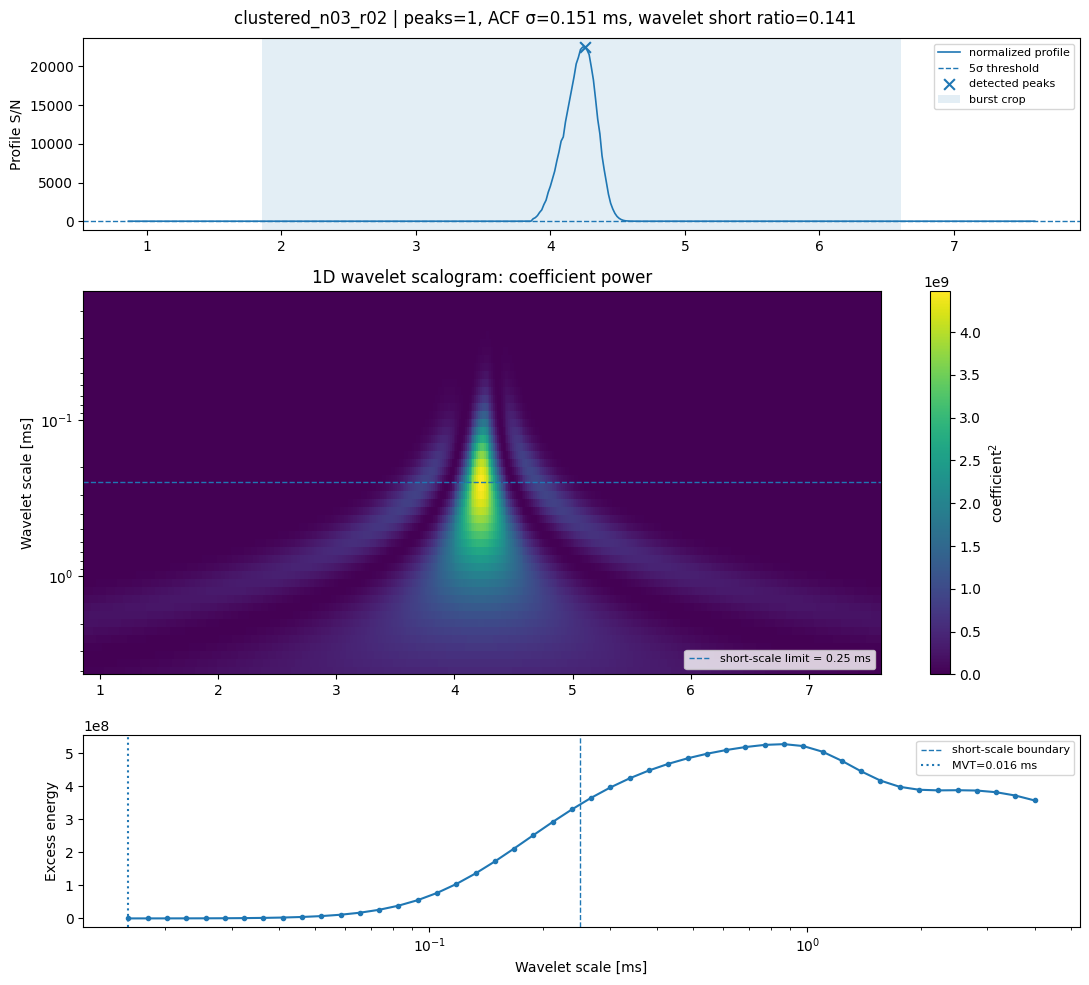

In [6]:
def plot_wavelet_burst(burst, profile_norm, crop_mask, peak_info, wave_info, title=None, save_path=None):
    t = burst["t_ms"]
    scale_ms = wave_info["wavelet_scale_ms"]
    coeffs = wave_info["wavelet_coeffs"]
    power_by_scale = wave_info["wavelet_excess_by_scale"]
    idx = np.where(crop_mask)[0]
    pad = int(round(1.0 / burst["tsamp_ms"]))
    start = max(0, idx.min() - pad) if idx.size else 0
    stop = min(len(t), idx.max() + pad + 1) if idx.size else len(t)
    sl = slice(start, stop)
    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False, gridspec_kw={"height_ratios": [1.0, 2.0, 1.0]})
    axes[0].plot(t[sl], profile_norm[sl], lw=1.2, label="normalized profile")
    axes[0].axhline(PEAK_SIGMA_THRESHOLD, ls="--", lw=1, label=f"{PEAK_SIGMA_THRESHOLD:g}σ threshold")
    pk = peak_info["peak_indices"]
    pk = pk[(pk >= start) & (pk < stop)]
    if pk.size:
        axes[0].scatter(t[pk], profile_norm[pk], marker="x", s=60, label="detected peaks")
    if np.any(crop_mask):
        axes[0].axvspan(t[crop_mask][0], t[crop_mask][-1], alpha=0.12, label="burst crop")
    axes[0].set_ylabel("Profile S/N")
    axes[0].legend(loc="upper right", fontsize=8)
    scalogram = coeffs[:, sl] ** 2
    im = axes[1].pcolormesh(t[sl], scale_ms, scalogram, shading="auto")
    axes[1].set_yscale("log")
    axes[1].invert_yaxis()
    axes[1].axhline(SHORT_SCALE_MAX_MS, ls="--", lw=1, label=f"short-scale limit = {SHORT_SCALE_MAX_MS:g} ms")
    axes[1].set_ylabel("Wavelet scale [ms]")
    axes[1].set_title("1D wavelet scalogram: coefficient power")
    fig.colorbar(im, ax=axes[1], label="coefficient$^2$")
    axes[1].legend(loc="lower right", fontsize=8)
    axes[2].plot(scale_ms, power_by_scale, marker="o", ms=3)
    axes[2].axvline(SHORT_SCALE_MAX_MS, ls="--", lw=1, label="short-scale boundary")
    if np.isfinite(wave_info["wavelet_mvt_ms"]):
        axes[2].axvline(wave_info["wavelet_mvt_ms"], ls=":", lw=1.5, label=f"MVT={wave_info['wavelet_mvt_ms']:.3g} ms")
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Wavelet scale [ms]")
    axes[2].set_ylabel("Excess energy")
    axes[2].legend(fontsize=8)
    if title is None:
        title = burst["burst_id"]
    fig.suptitle(
        f"{title} | peaks={peak_info['peak_count']}, ACF σ={acf_sigma:.3g} ms, "
        f"wavelet short ratio={wave_info['wavelet_short_energy_ratio']:.3g}",
        y=0.98,
    )
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=160)
    return fig

fig = plot_wavelet_burst(example, profile_norm, crop_mask, peak_info, wave_info)
plt.show()

## Batch analysis

This computes ACF, peak, and wavelet metrics for every `.npz` burst. The main output is `wavelet_microshot_results.csv`.

In [18]:
def analyze_one_burst_wavelets(path):
    burst = load_burst_npz(path)
    t = burst["t_ms"]
    tsamp_ms = burst["tsamp_ms"]
    profile_norm, med, sig = normalize_profile(burst["profile"])
    start, stop, crop_mask = find_burst_crop(t, profile_norm)
    acf_sigma, acf_resid_rms = compute_acf_sigma(t, profile_norm, crop_mask=crop_mask)
    peak_info = detect_peaks_and_metrics(t, profile_norm, crop_mask=crop_mask)
    wave_info = wavelet_profile_metrics(t, profile_norm, crop_mask, tsamp_ms)
    ds_wave = {}
    if RUN_DYNAMIC_SPECTRUM_TIME_WAVELET and burst["dynamic_spectrum"] is not None:
        ds_wave = dynamic_spectrum_time_wavelet_metrics(burst["dynamic_spectrum"], crop_mask, tsamp_ms)
    row = dict(
        file=burst["file"],
        burst_id=burst["burst_id"],
        dm=burst["dm"],
        input_n_peaks=burst["input_n_peaks"],
        nt=len(t),
        nf=burst["dynamic_spectrum"].shape[1] if burst["dynamic_spectrum"] is not None else np.nan,
        tsamp_ms=tsamp_ms,
        crop_start_ms=float(t[start]),
        crop_end_ms=float(t[stop-1]),
        crop_duration_ms=float(t[stop-1] - t[start] + tsamp_ms),
        acf_sigma_ms=acf_sigma,
        acf_resid_rms=acf_resid_rms,
        peak_count=peak_info["peak_count"],
        peak_rate_per_ms=peak_info["peak_rate_per_ms"],
        sep_mean_ms=peak_info["sep_mean_ms"],
        sep_std_ms=peak_info["sep_std_ms"],
        sep_cv=peak_info["sep_cv"],
        peak_width_median_ms=peak_info["peak_width_median_ms"],
        peak_height_max=peak_info["peak_height_max"],
        amplitude_entropy=peak_info["amplitude_entropy"],
        t90_ms=peak_info["t90_ms"],
        wavelet_short_energy_ratio=wave_info["wavelet_short_energy_ratio"],
        wavelet_spikiness=wave_info["wavelet_spikiness"],
        wavelet_rms=wave_info["wavelet_rms"],
        wavelet_max_abs_coeff=wave_info["wavelet_max_abs_coeff"],
        wavelet_intermittency=wave_info["wavelet_intermittency"],
        wavelet_mvt_ms=wave_info["wavelet_mvt_ms"],
        wavelet_char_scale_ms=wave_info["wavelet_char_scale_ms"],
        wavelet_scale_entropy=wave_info["wavelet_scale_entropy"],
        wavelet_total_excess_energy=wave_info["wavelet_total_excess_energy"],
        wavelet_short_energy=wave_info["wavelet_short_energy"],
    )
    row.update(ds_wave)
    return row

rows = []
failed = []

for i, path in enumerate(files, start=1):
    try:
        row = analyze_one_burst_wavelets(path)
        rows.append(row)
        print(f"OK {i}/{len(files)}: {path.name}")

    except Exception as e:
        failed.append({
            "file": str(path),
            "error": repr(e),
        })
        print(f"FAILED {i}/{len(files)}: {path.name}")
        print("   ", repr(e))

wave_df = pd.DataFrame(rows)
failed_df = pd.DataFrame(failed)

wave_csv = OUT_DIR / "wavelet_microshot_results.csv"
failed_csv = OUT_DIR / "wavelet_microshot_failed.csv"

wave_df.to_csv(wave_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

print("Saved:", wave_csv)
print("Successful:", len(wave_df))
print("Failed:", len(failed_df), "saved to", failed_csv)

display(wave_df.head())
display(failed_df.head())

OK 1/26: clustered_n03_r02.npz
OK 2/26: clustered_n03_r04.npz
OK 3/26: clustered_n03_r05.npz
OK 4/26: clustered_n06_r02.npz
OK 5/26: clustered_n06_r03.npz
OK 6/26: clustered_n12_r00.npz
OK 7/26: clustered_n24_r03.npz
OK 8/26: dense_n06_r03.npz
OK 9/26: dense_n12_r02.npz
OK 10/26: moderate_n03_r00.npz
OK 11/26: moderate_n03_r04.npz
OK 12/26: moderate_n06_r00.npz
OK 13/26: moderate_n06_r02.npz
OK 14/26: moderate_n06_r04.npz
OK 15/26: moderate_n12_r00.npz
OK 16/26: moderate_n24_r00.npz
OK 17/26: quasiperiodic_n36_r00.npz
OK 18/26: quasiperiodic_n36_r02.npz
OK 19/26: quasiperiodic_n36_r03.npz
OK 20/26: sparse_n03_r03.npz
OK 21/26: sparse_n06_r01.npz
OK 22/26: sparse_n12_r01.npz
OK 23/26: sparse_n24_r03.npz
OK 24/26: sparse_n36_r00.npz
OK 25/26: sparse_n36_r03.npz
OK 26/26: sparse_n36_r05.npz
Saved: wavelet_microshot_results/wavelet_microshot_results.csv
Successful: 26
Failed: 0 saved to wavelet_microshot_results/wavelet_microshot_failed.csv


,file,burst_id,dm,input_n_peaks,nt,nf,tsamp_ms,crop_start_ms,crop_end_ms,crop_duration_ms,...,wavelet_max_abs_coeff,wavelet_intermittency,wavelet_mvt_ms,wavelet_char_scale_ms,wavelet_scale_entropy,wavelet_total_excess_energy,wavelet_short_energy,ds_wavelet_short_energy_ratio,ds_wavelet_spikiness,ds_wavelet_char_scale_ms
0,will_flits_microshot_package/will_microshot_ou...,clustered_n03_r02,220.0,3,30289,128,0.016,1.856,6.608,4.768,...,66938.575099,4.173132,0.016,0.86856,0.891610,1.233738e+10,1.741745e+09,0.140453,1486.605200,0.976
1,will_flits_microshot_package/will_microshot_ou...,clustered_n03_r04,220.0,3,30289,128,0.016,2.208,9.008,6.816,...,45381.554107,3.962792,0.016,4.00000,0.889322,6.284140e+09,9.282301e+08,0.250178,1937.935322,0.496
2,will_flits_microshot_package/will_microshot_ou...,clustered_n03_r05,220.0,3,30289,128,0.016,4.080,8.864,4.800,...,57733.812124,3.959424,0.016,0.86856,0.889765,1.019216e+10,1.258630e+09,0.202707,1710.648172,0.832
3,will_flits_microshot_package/will_microshot_ou...,clustered_n06_r02,220.0,6,30289,128,0.016,1.872,8.448,6.592,...,51884.972477,2.802189,0.016,4.00000,0.855340,1.642160e+10,1.381129e+09,0.135717,1545.415043,1.648
4,will_flits_microshot_package/will_microshot_ou...,clustered_n06_r03,220.0,6,30289,128,0.016,3.168,7.952,4.800,...,67240.513295,4.132935,0.016,0.86856,0.889504,1.269023e+10,1.707284e+09,0.179243,1383.687544,0.832


""


## Merge with FLITS results

This makes it possible to compare wavelet spikiness with the FLITS residual diagnostics from the previous notebook.

In [22]:
def merge_with_flits(wave_df, flits_csv):
    flits_csv = FLITS_RESULTS_CSV
    if not flits_csv.exists():
        print("No FLITS CSV found; using wavelet table only.")
        return wave_df.copy()
    flits_df = pd.read_csv(flits_csv)
    keep_cols = [
        "burst_id",
        "flits_fit_duration_ms",
        "flits_width_ms",
        "flits_tau_1ghz_ms",
        "flits_width_upper_ms",
        "flits_tau_upper_ms",
        "flits_profile_chi2_red",
        "flits_profile_r_squared",
        "flits_profile_resid_rms",
        "flits_profile_quality_flag",
        "flits_quality_flag",
    ]
    keep_cols = [col for col in keep_cols if col in flits_df.columns]
    return wave_df.merge(flits_df[keep_cols], on="burst_id", how="left", suffixes=("", "_flits"))

merged_df = merge_with_flits(wave_df, FLITS_RESULTS_CSV)
merged_csv = OUT_DIR / "wavelet_flits_merged_results.csv"
merged_df.to_csv(merged_csv, index=False)
print("Saved merged table:", merged_csv)

cols = [
    "burst_id", "input_n_peaks", "acf_sigma_ms", "peak_count", "peak_rate_per_ms", "sep_cv",
    "wavelet_short_energy_ratio", "wavelet_spikiness", "wavelet_mvt_ms", "wavelet_char_scale_ms",
    "flits_profile_r_squared", "flits_profile_resid_rms", "flits_profile_quality_flag",
]
cols = [col for col in cols if col in merged_df.columns]
merged_df[cols].sort_values("peak_count").head(10)

Saved merged table: wavelet_microshot_results/wavelet_flits_merged_results.csv


,burst_id,input_n_peaks,acf_sigma_ms,peak_count,peak_rate_per_ms,sep_cv,wavelet_short_energy_ratio,wavelet_spikiness,wavelet_mvt_ms,wavelet_char_scale_ms,flits_profile_r_squared,flits_profile_resid_rms,flits_profile_quality_flag
0,clustered_n03_r02,3,0.151356,1,0.209732,NaN,0.141176,8518.962234,0.016,0.868560,-0.146245,0.294919,FAIL
2,clustered_n03_r05,3,0.170921,2,0.416667,0.000000,0.123490,7241.747611,0.016,0.868560,0.234325,0.208241,MARGINAL
4,clustered_n06_r03,6,0.156472,2,0.416667,0.000000,0.134535,8434.266475,0.016,0.868560,0.173665,0.234826,FAIL
19,sparse_n03_r03,3,0.126046,3,0.341530,0.863636,0.180436,3496.392873,0.016,0.976832,-0.137682,0.255017,FAIL
1,clustered_n03_r04,3,0.146969,4,0.586854,0.968147,0.147710,6219.023499,0.016,4.000000,-0.148826,0.280061,FAIL
10,moderate_n03_r04,3,0.158840,5,0.851499,0.585943,0.123984,8080.288045,0.016,3.556641,-0.019463,0.259337,FAIL
8,dense_n12_r02,12,0.220230,5,0.733568,0.431958,0.087765,6340.744872,0.016,1.562788,0.063782,0.267925,FAIL
3,clustered_n06_r02,6,0.217565,6,0.910194,0.241557,0.084104,7585.975710,0.016,4.000000,-0.122406,0.275020,FAIL
20,sparse_n06_r01,6,0.285775,6,0.541126,1.714943,0.119139,5242.775275,0.016,1.757600,-0.216133,0.317560,FAIL
7,dense_n06_r03,6,0.170638,7,0.965784,0.720753,0.095720,7064.054977,0.016,4.000000,0.055738,0.235769,FAIL


## Correlation table

This checks which metrics track the injected or detected complexity. Spearman correlation is used because the relation does not need to be linear.

In [23]:
def spearman_table(df, target_cols, metric_cols):
    rows = []
    for target in target_cols:
        if target not in df.columns:
            continue
        for col in metric_cols:
            if col not in df.columns or col == target:
                continue
            x = pd.to_numeric(df[col], errors="coerce")
            y = pd.to_numeric(df[target], errors="coerce")
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() >= 4:
                rho, p = stats.spearmanr(x[mask], y[mask])
                rows.append({"target": target, "metric": col, "spearman_rho": rho, "pvalue": p, "n": int(mask.sum())})
    return pd.DataFrame(rows).sort_values(["target", "spearman_rho"], ascending=[True, False])

metric_cols = [
    "acf_sigma_ms", "acf_resid_rms", "peak_rate_per_ms", "sep_cv", "amplitude_entropy", "t90_ms",
    "wavelet_short_energy_ratio", "wavelet_spikiness", "wavelet_rms", "wavelet_intermittency",
    "wavelet_mvt_ms", "wavelet_char_scale_ms", "wavelet_scale_entropy",
    "ds_wavelet_time_short_ratio", "ds_wavelet_time_char_scale_ms", "ds_wavelet_time_scale_entropy",
    "flits_profile_r_squared", "flits_profile_resid_rms", "flits_profile_chi2_red",
]
target_cols = ["input_n_peaks", "peak_count"]

corr_df = spearman_table(merged_df, target_cols, metric_cols)
corr_csv = OUT_DIR / "wavelet_metric_correlations.csv"
corr_df.to_csv(corr_csv, index=False)
print("Saved:", corr_csv)
corr_df.head(25)

Saved: wavelet_microshot_results/wavelet_metric_correlations.csv


/tmp/ipykernel_20928/1287131039.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(x[mask], y[mask])


,target,metric,spearman_rho,pvalue,n
2,input_n_peaks,peak_rate_per_ms,0.905351,2.089209e-10,26
5,input_n_peaks,t90_ms,0.693378,8.591189e-05,26
13,input_n_peaks,flits_profile_r_squared,0.663247,2.216078e-04,26
11,input_n_peaks,wavelet_char_scale_ms,0.634331,5.011581e-04,26
4,input_n_peaks,amplitude_entropy,0.612443,8.820907e-04,26
9,input_n_peaks,wavelet_intermittency,0.295010,1.434478e-01,26
0,input_n_peaks,acf_sigma_ms,0.293608,1.454490e-01,26
3,input_n_peaks,sep_cv,0.262199,2.054526e-01,25
1,input_n_peaks,acf_resid_rms,0.118424,5.644908e-01,26
8,input_n_peaks,wavelet_rms,-0.340558,8.867565e-02,26


## Diagnostic scatter plots

These figures test whether wavelet metrics separate bursts better than ACF timescale alone.

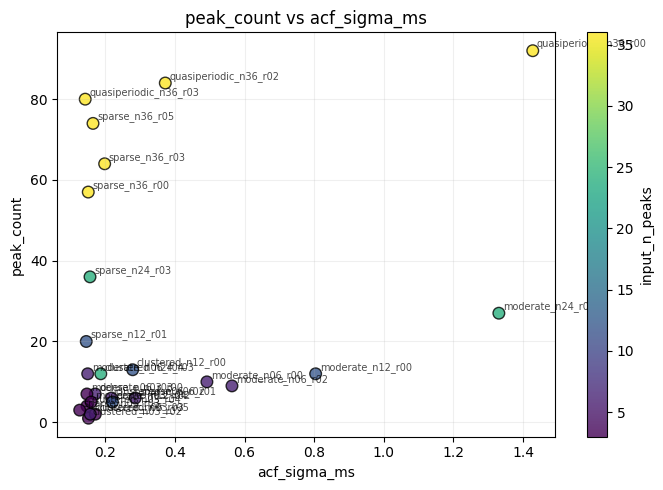

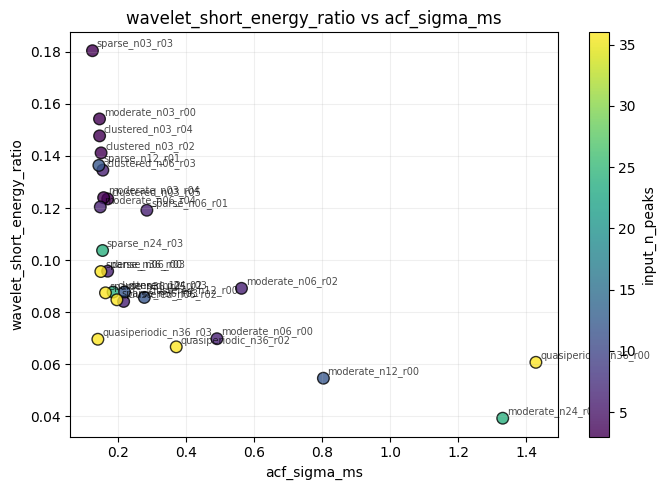

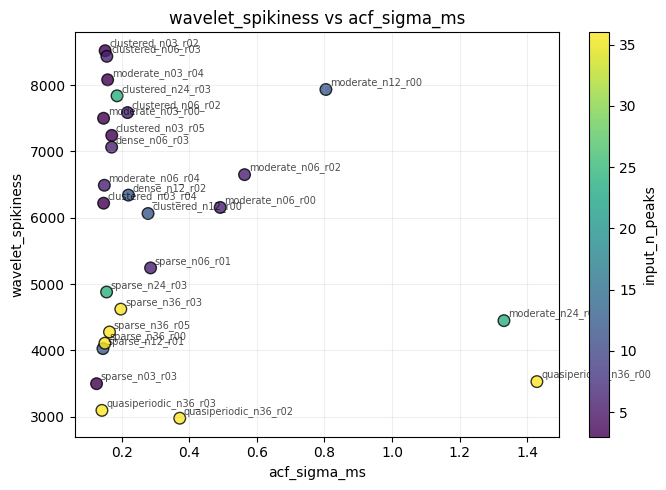

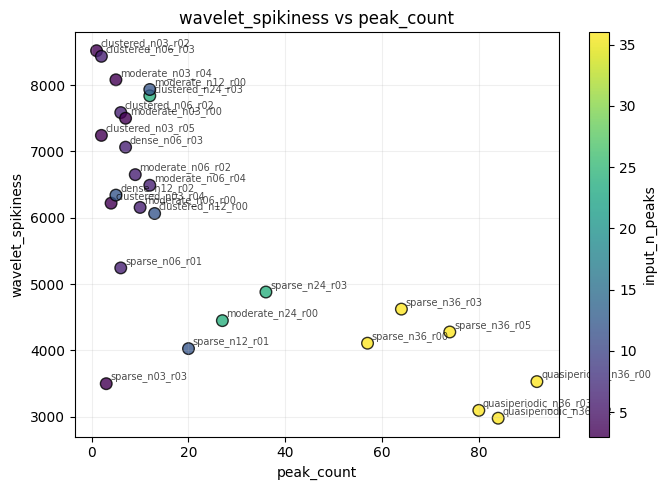

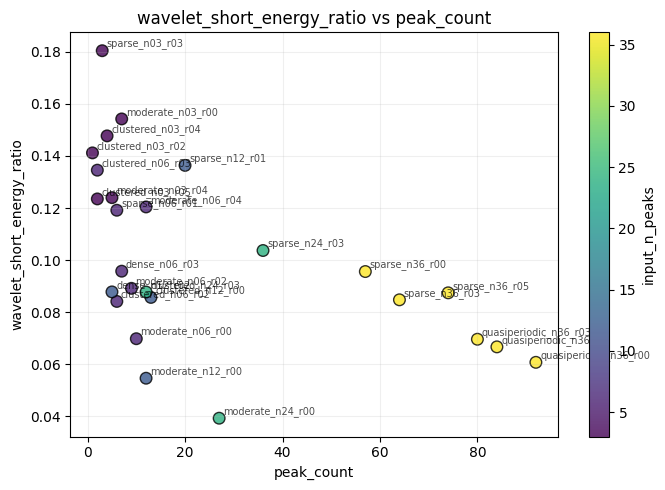

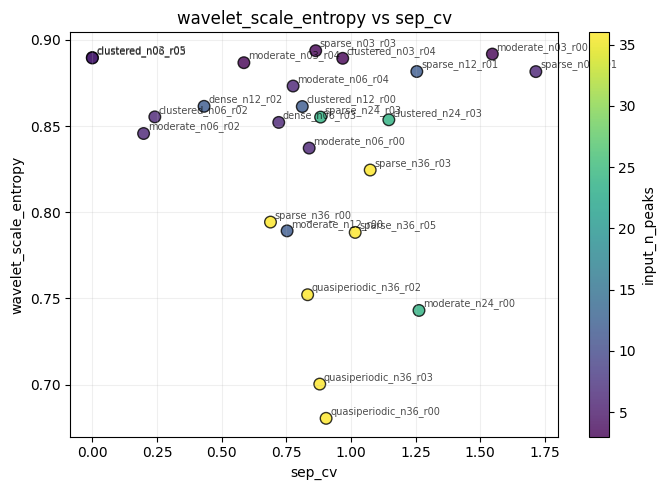

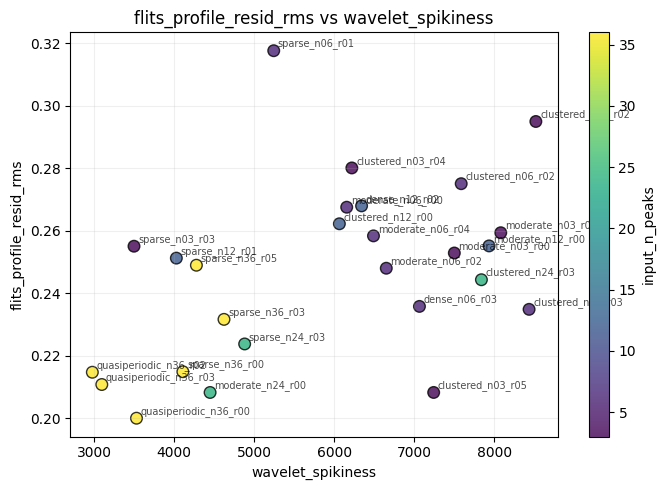

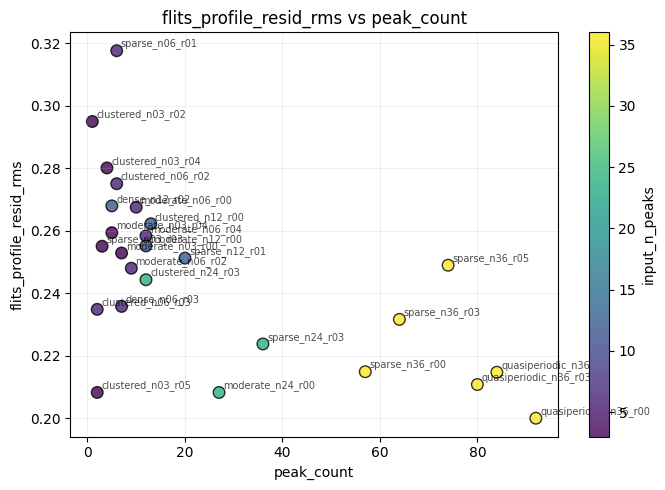

In [24]:
def scatter_with_color(df, x, y, color="input_n_peaks", save_path=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    xx = pd.to_numeric(df[x], errors="coerce")
    yy = pd.to_numeric(df[y], errors="coerce")
    cc = pd.to_numeric(df[color], errors="coerce") if color in df.columns else None
    mask = np.isfinite(xx) & np.isfinite(yy)
    if cc is not None:
        mask &= np.isfinite(cc)
        sc = ax.scatter(xx[mask], yy[mask], c=cc[mask], s=70, edgecolor="k", alpha=0.8)
        cb = fig.colorbar(sc, ax=ax)
        cb.set_label(color)
    else:
        ax.scatter(xx[mask], yy[mask], s=70, edgecolor="k", alpha=0.8)
    for _, r in df[mask].iterrows():
        ax.annotate(str(r["burst_id"]), (r[x], r[y]), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=160)
    return fig

plots = [
    ("acf_sigma_ms", "peak_count"),
    ("acf_sigma_ms", "wavelet_short_energy_ratio"),
    ("acf_sigma_ms", "wavelet_spikiness"),
    ("peak_count", "wavelet_spikiness"),
    ("peak_count", "wavelet_short_energy_ratio"),
    ("sep_cv", "wavelet_scale_entropy"),
]
if "flits_profile_resid_rms" in merged_df.columns:
    plots.extend([
        ("wavelet_spikiness", "flits_profile_resid_rms"),
        ("peak_count", "flits_profile_resid_rms"),
    ])

for x, y in plots:
    if x in merged_df.columns and y in merged_df.columns:
        fig = scatter_with_color(merged_df, x, y, save_path=OUT_DIR / f"scatter_{y}_vs_{x}.png")
        plt.show()

## Select bursts with similar ACF timescale but different wavelet spikiness


In [25]:
def select_similar_acf_different_wavelet(df, tau_col="acf_sigma_ms",
                                        wave_col="wavelet_spikiness",
                                        tolerance_fraction=0.25,
                                        min_group_size=2):
    d = df.copy()
    d[tau_col] = pd.to_numeric(d[tau_col], errors="coerce")
    d[wave_col] = pd.to_numeric(d[wave_col], errors="coerce")
    d = d[np.isfinite(d[tau_col]) & np.isfinite(d[wave_col])].copy()
    best = None
    best_score = -np.inf
    for _, row in d.iterrows():
        tau = row[tau_col]
        if tau <= 0:
            continue
        group = d[np.abs(d[tau_col] - tau) <= tolerance_fraction * tau].copy()
        if len(group) < min_group_size:
            continue
        wave_range = group[wave_col].max() - group[wave_col].min()
        peak_range = group["peak_count"].max() - group["peak_count"].min() if "peak_count" in group.columns else 0
        score = wave_range * (1 + 0.05 * peak_range) * np.sqrt(len(group))
        if score > best_score:
            best_score = score
            best = group.sort_values(wave_col)
    return best if best is not None else pd.DataFrame()

selected = select_similar_acf_different_wavelet(
    merged_df,
    tau_col="acf_sigma_ms",
    wave_col="wavelet_spikiness",
    tolerance_fraction=0.25,
)
selected_csv = OUT_DIR / "selected_similar_acf_different_wavelet.csv"
selected.to_csv(selected_csv, index=False)
print("Saved:", selected_csv)

show_cols = [
    "burst_id", "input_n_peaks", "acf_sigma_ms", "peak_count", "peak_rate_per_ms", "sep_cv",
    "wavelet_spikiness", "wavelet_short_energy_ratio", "wavelet_mvt_ms", "wavelet_char_scale_ms",
    "flits_profile_r_squared", "flits_profile_resid_rms", "flits_profile_quality_flag",
]
show_cols = [col for col in show_cols if col in selected.columns]
selected[show_cols]

Saved: wavelet_microshot_results/selected_similar_acf_different_wavelet.csv


,burst_id,input_n_peaks,acf_sigma_ms,peak_count,peak_rate_per_ms,sep_cv,wavelet_spikiness,wavelet_short_energy_ratio,wavelet_mvt_ms,wavelet_char_scale_ms,flits_profile_r_squared,flits_profile_resid_rms,flits_profile_quality_flag
18,quasiperiodic_n36_r03,36,0.141908,80,6.119951,0.879344,3093.853990,0.069568,0.016,4.000000,0.303119,0.210781,MARGINAL
21,sparse_n12_r01,12,0.144885,20,1.539409,1.254603,4025.562160,0.136368,0.016,4.000000,-0.081589,0.251212,FAIL
23,sparse_n36_r00,36,0.150648,57,4.419975,0.688825,4106.901405,0.095586,0.016,4.000000,0.300243,0.214874,MARGINAL
25,sparse_n36_r05,36,0.164294,74,5.731103,1.016346,4276.250296,0.087406,0.016,4.000000,0.140801,0.248937,FAIL
24,sparse_n36_r03,36,0.197757,64,4.944376,1.074406,4621.069989,0.084725,0.016,4.000000,0.221318,0.231619,MARGINAL
22,sparse_n24_r03,24,0.155697,36,2.784653,0.882621,4879.237449,0.103666,0.016,4.000000,0.170033,0.223757,FAIL
1,clustered_n03_r04,3,0.146969,4,0.586854,0.968147,6219.023499,0.147710,0.016,4.000000,-0.148826,0.280061,FAIL
8,dense_n12_r02,12,0.220230,5,0.733568,0.431958,6340.744872,0.087765,0.016,1.562788,0.063782,0.267925,FAIL
13,moderate_n06_r04,6,0.149022,12,1.368613,0.776192,6489.395342,0.120406,0.016,4.000000,0.023438,0.258331,FAIL
7,dense_n06_r03,6,0.170638,7,0.965784,0.720753,7064.054977,0.095720,0.016,4.000000,0.055738,0.235769,FAIL


## Compare the least-spiky and most-spiky bursts in the selected group


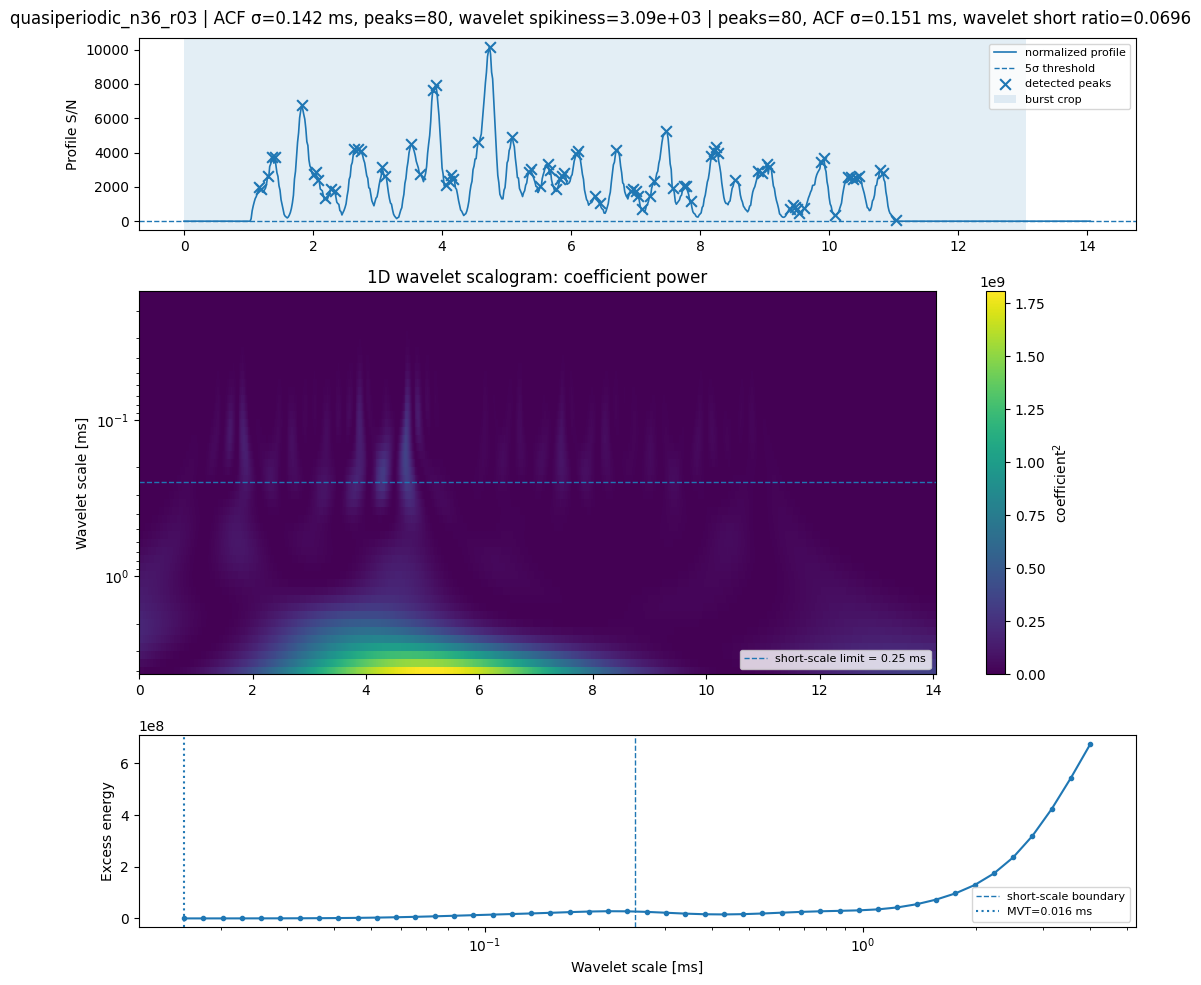

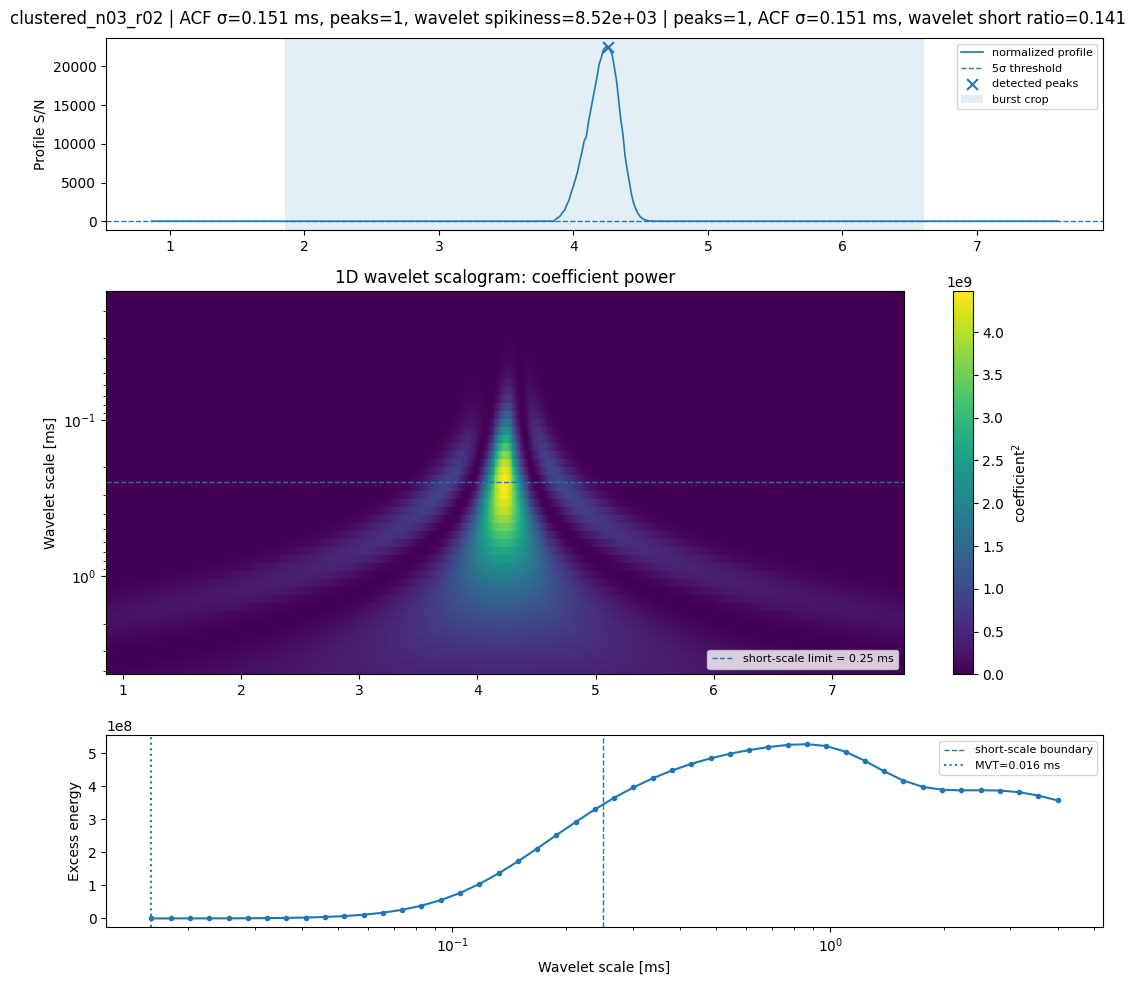

In [26]:
def load_and_compute_for_plot(row):
    burst = load_burst_npz(row["file"])
    profile_norm, _, _ = normalize_profile(burst["profile"])
    start, stop, crop_mask = find_burst_crop(burst["t_ms"], profile_norm)
    peak_info = detect_peaks_and_metrics(burst["t_ms"], profile_norm, crop_mask=crop_mask)
    wave_info = wavelet_profile_metrics(burst["t_ms"], profile_norm, crop_mask, burst["tsamp_ms"])
    return burst, profile_norm, crop_mask, peak_info, wave_info

if len(selected) >= 2:
    pair = pd.concat([selected.head(1), selected.tail(1)])
    for _, row in pair.iterrows():
        burst, pnorm, cmask, pinfo, winfo = load_and_compute_for_plot(row)
        title = (
            f"{burst['burst_id']} | ACF σ={row['acf_sigma_ms']:.3g} ms, "
            f"peaks={row['peak_count']}, wavelet spikiness={row['wavelet_spikiness']:.3g}"
        )
        fig = plot_wavelet_burst(
            burst, pnorm, cmask, pinfo, winfo, title=title,
            save_path=OUT_DIR / f"wavelet_scalogram_{burst['burst_id']}.png",
        )
        plt.show()
else:
    print("No selected pair found. Try increasing tolerance_fraction in the previous cell.")

## Dynamic-spectrum crop for the selected pair

This helps check whether the 1D wavelet result corresponds to real time-frequency structure.

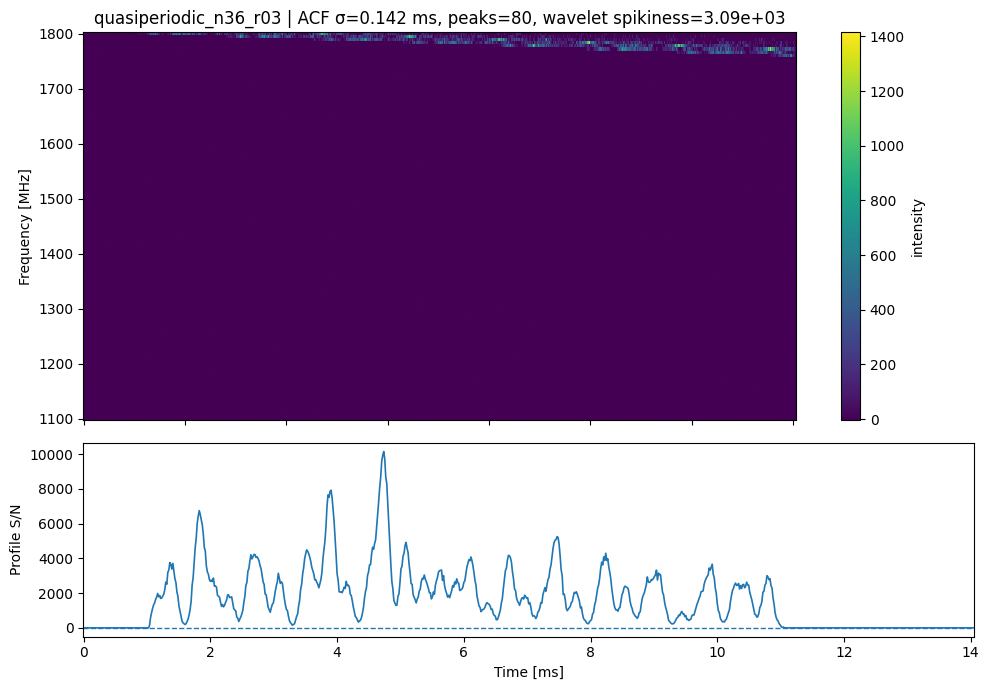

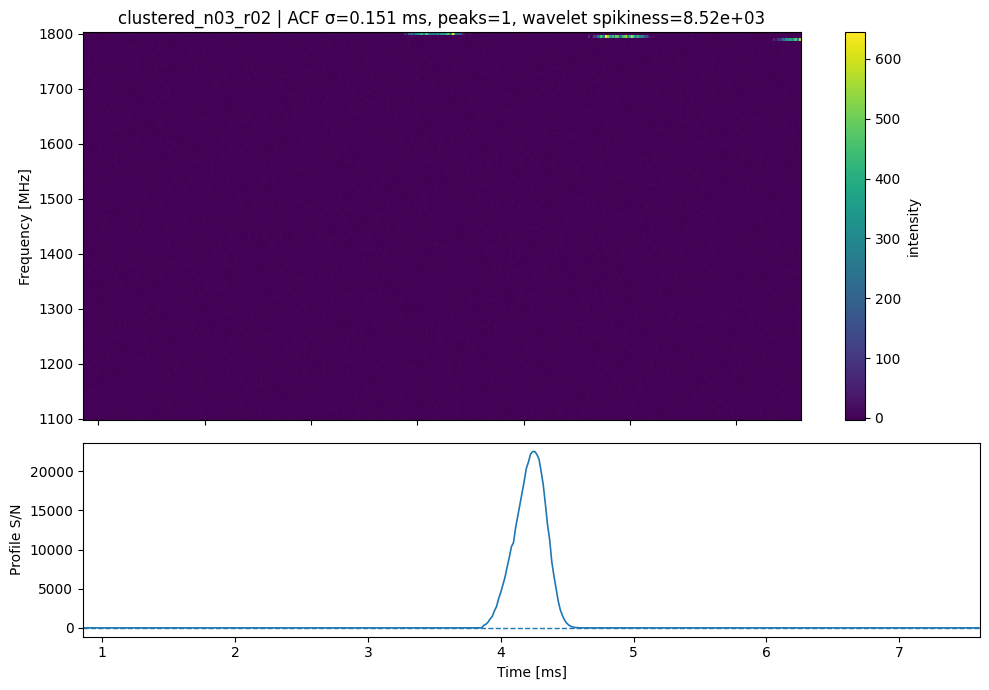

In [27]:
def plot_dynamic_spectrum_crop(row, save_path=None):
    burst = load_burst_npz(row["file"])
    ds = burst["dynamic_spectrum"]
    if ds is None:
        print("No dynamic spectrum for", burst["burst_id"])
        return None
    pnorm, _, _ = normalize_profile(burst["profile"])
    start, stop, crop_mask = find_burst_crop(burst["t_ms"], pnorm)
    idx = np.where(crop_mask)[0]
    pad = int(round(1.0 / burst["tsamp_ms"]))
    s = max(0, idx.min() - pad)
    e = min(len(burst["t_ms"]), idx.max() + pad + 1)
    t = burst["t_ms"][s:e]
    freqs = burst["freqs_mhz"]
    arr = ds[s:e, :].T
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    im = axes[0].pcolormesh(t, freqs, arr, shading="auto")
    fig.colorbar(im, ax=axes[0], label="intensity")
    axes[0].set_ylabel("Frequency [MHz]")
    axes[0].set_title(
        f"{burst['burst_id']} | ACF σ={row['acf_sigma_ms']:.3g} ms, "
        f"peaks={row['peak_count']}, wavelet spikiness={row['wavelet_spikiness']:.3g}"
    )
    axes[1].plot(t, pnorm[s:e], lw=1.2)
    axes[1].axhline(PEAK_SIGMA_THRESHOLD, ls="--", lw=1)
    axes[1].set_xlabel("Time [ms]")
    axes[1].set_ylabel("Profile S/N")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=160)
    return fig

if len(selected) >= 2:
    pair = pd.concat([selected.head(1), selected.tail(1)])
    for _, row in pair.iterrows():
        fig = plot_dynamic_spectrum_crop(row, save_path=OUT_DIR / f"dynamic_spectrum_crop_{row['burst_id']}.png")
        plt.show()
else:
    print("No selected pair found.")